# 05b2 — Robustness Sweeps (Scenario A): QAOA (QUBO) with Aer (Final)

This standalone notebook is the **Aer-enabled, optimized** QAOA robustness sweep for Scenario A.

It is intentionally separate from `05b_robustness_sweeps_scenario_A_qaoa.ipynb` so you can:
- keep the earlier notebook as a working reference (Aer-free),
- run a higher-quality Aer-backed sweep (this notebook),
- avoid overwriting prior artifacts / tags.

## Objective
Select **exactly K** trials from a **fixed pool** (same candidates/qubits for every config) by minimizing:

**Objective(x) = Σᵢ wᵢ xᵢ + A(Σᵢ xᵢ − K)²**

Where:
- xᵢ ∈ {0,1}
- wᵢ = -benefit + λ_cost·cost + λ_safety·safety_penalty
- A is the exact-K penalty strength

## Outputs (05b2 prefix)
Writes:
- `data/results/05b2_qaoa_aer_robustness_sweep_summary.csv`
- `data/results/05b2_qaoa_aer_top_config_table.csv`
- `data/results/05b2_qaoa_aer_top_configs_selected_trials.csv`
- `data/results/05b2_qaoa_aer_checkpoint_partial.csv` (intermediate)
- figures in `outputs/figures/`:
  - `05b2_qaoa_aer_objective_heatmap.png`
  - `05b2_qaoa_aer_jaccard_vs_baseline.png`

Notes:
- Requires `qiskit-aer` available in the running kernel environment.
- Uses p=1 QAOA with a (γ,β) grid search.
- Uses a **fixed candidate pool** built once from baseline weights to make stability comparisons meaningful.


In [1]:
# ============================================================
# Cell 1 — Setup: imports, paths, environment checks
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

# --- Qiskit / Aer check ---
HAVE_AER = False
try:
    from qiskit import QuantumCircuit, transpile
    from qiskit_aer import AerSimulator
    HAVE_AER = True
except Exception:
    HAVE_AER = False

print("Aer available:", HAVE_AER)
if not HAVE_AER:
    raise RuntimeError(
        "Qiskit Aer is required for this Aer-optimized notebook.\n"
        "Fix: install qiskit-aer in this kernel environment, restart kernel, and rerun."
    )

# --- Project directories ---
RESULTS_DIR = Path("data/results")
FIG_DIR = Path("outputs/figures")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Input candidates (Scenario A) ---
# Set this *one* variable if your candidates live elsewhere.
PATH_CANDIDATES_PRIMARY = Path("data/processed/scenario_A_candidates.csv")

# --- Output naming (standalone prefix) ---
OUT_PREFIX = "05b2_qaoa_aer"

PATH_SWEEP_SUMMARY = RESULTS_DIR / f"{OUT_PREFIX}_robustness_sweep_summary.csv"
PATH_TOP_TABLE     = RESULTS_DIR / f"{OUT_PREFIX}_top_config_table.csv"
PATH_TOP_SELECTED  = RESULTS_DIR / f"{OUT_PREFIX}_top_configs_selected_trials.csv"
PATH_CHECKPOINT    = RESULTS_DIR / f"{OUT_PREFIX}_checkpoint_partial.csv"

PATH_FIG_HEATMAP   = FIG_DIR / f"{OUT_PREFIX}_objective_heatmap.png"
PATH_FIG_JACCARD   = FIG_DIR / f"{OUT_PREFIX}_jaccard_vs_baseline.png"

print("Results dir:", RESULTS_DIR.resolve())
print("Figures dir:", FIG_DIR.resolve())
print("Candidates (primary):", PATH_CANDIDATES_PRIMARY)

Aer available: True
Results dir: /home/parallels/projects/quantum-clinical-trial-optimization/data/results
Figures dir: /home/parallels/projects/quantum-clinical-trial-optimization/outputs/figures
Candidates (primary): data/processed/scenario_A_candidates.csv


### What Cell 1 Just Did

- Imported core libraries and verified Aer is available in the current Jupyter kernel.
- Defined input and output paths using a standalone prefix (`05b2_qaoa_aer_*`) so no prior results are overwritten.
- Established a single primary candidates path you can edit if your repo stores candidates elsewhere.


In [2]:
# ============================================================
# Cell 2 — Reproducibility: record Qiskit versions (recommended for slide notes)
# ============================================================

import importlib

def _version(pkg_name: str):
    try:
        mod = importlib.import_module(pkg_name)
        return getattr(mod, "__version__", "unknown")
    except Exception as e:
        return f"not importable ({e.__class__.__name__})"

print("qiskit:", _version("qiskit"))
print("qiskit_aer:", _version("qiskit_aer"))

# Aer backend details (version-safe: some versions expose .name as a string attribute)
sim = AerSimulator()
backend_name_attr = getattr(sim, "name", None)
backend_name = backend_name_attr if isinstance(backend_name_attr, str) else sim.name()
print("AerSimulator backend:", backend_name)

qiskit: 2.2.3
qiskit_aer: 0.17.2
AerSimulator backend: aer_simulator


### What Cell 2 Just Did

- Printed the Qiskit and Aer versions from the active environment.
- This makes results easier to reproduce later and helps explain performance differences between runs.

In [5]:
# ============================================================
# Cell 3 — Load candidates + build scoring components (benefit/cost/safety)
# ============================================================

from pathlib import Path

def find_candidate_file() -> Path:
    """
    Try hard to locate a Scenario A candidates/scored dataset in the repo.
    Prefers explicit 'scenario_A' + 'candidate' + CSV, otherwise falls back to scored CSVs.
    """
    roots = [Path("data/processed"), Path("data/interim"), Path("data/results"), Path("data/raw"), Path("data")]
    patterns = [
        "*scenario*A*candidate*.csv",
        "*scenario*A*scor*.csv",
        "*03e*scenario*A*.csv",
        "*scenario*A*.csv",
    ]

    hits = []
    for root in roots:
        if not root.exists():
            continue
        for pat in patterns:
            hits.extend(root.rglob(pat))

    # keep only files
    hits = [p for p in hits if p.is_file()]

    # scoring heuristic: prefer files that look like candidates AND scored
    def score_path(p: Path) -> tuple:
        s = str(p).lower()
        score = 0
        score += 5 if "scenario" in s else 0
        score += 5 if "scenario_a" in s or "scenario-a" in s or "scenario a" in s else 0
        score += 4 if "candidate" in s else 0
        score += 3 if "scor" in s else 0
        score += 2 if "03e" in s else 0
        score += 1 if "processed" in s else 0
        # prefer shallower paths slightly (often "final-ish")
        depth_penalty = len(p.parts)
        return (-score, depth_penalty, s)

    hits_sorted = sorted(set(hits), key=score_path)

    if hits_sorted:
        print("Candidate file auto-discovery: top matches")
        for p in hits_sorted[:10]:
            print("  -", p)
        return hits_sorted[0]

    return None

# If you want to hardcode, set this to a real path; otherwise leave as None.
PATH_CANDIDATES_PRIMARY = globals().get("PATH_CANDIDATES_PRIMARY", None)
if PATH_CANDIDATES_PRIMARY and Path(PATH_CANDIDATES_PRIMARY).exists():
    PATH_CANDIDATES = Path(PATH_CANDIDATES_PRIMARY)
    print("Using PATH_CANDIDATES_PRIMARY:", PATH_CANDIDATES)
else:
    PATH_CANDIDATES = find_candidate_file()

if PATH_CANDIDATES is None:
    raise FileNotFoundError(
        "Could not auto-locate a Scenario A candidates CSV under data/.\n"
        "Fix options:\n"
        "  1) Put the candidates CSV under data/processed or data/results\n"
        "  2) Or set PATH_CANDIDATES_PRIMARY in Cell 1 to the correct CSV path\n"
        "Helpful command:\n"
        "  find data -maxdepth 4 -type f -name '*.csv' | head\n"
    )

candidates = pd.read_csv(PATH_CANDIDATES)

# --- Required base identifiers ---
if "nct_id" not in candidates.columns:
    raise ValueError(
        "Candidates file missing required column: nct_id\n"
        f"Loaded: {PATH_CANDIDATES}\n"
        f"Columns present: {list(candidates.columns)}"
    )

# --- Robust column detection for scoring primitives ---
benefit_candidates = ["benefit_score", "benefit", "score_benefit"]
cost_candidates    = ["estimated_trial_cost", "trial_cost", "cost", "estimated_cost"]
feas_candidates    = ["enrollment_feasibility_score", "feasibility_score", "safety_score", "feasibility"]

def first_present(colnames, df):
    for c in colnames:
        if c in df.columns:
            return c
    return None

bcol = first_present(benefit_candidates, candidates)
ccol = first_present(cost_candidates, candidates)
fcol = first_present(feas_candidates, candidates)

if bcol is None or ccol is None or fcol is None:
    raise ValueError(
        "Missing required scoring columns in candidates.\n"
        f"Loaded: {PATH_CANDIDATES}\n"
        f"Found: benefit={bcol}, cost={ccol}, feasibility/safety={fcol}\n"
        f"Columns present: {list(candidates.columns)}\n"
        "Fix: ensure candidates include benefit_score, estimated_trial_cost, and enrollment_feasibility_score\n"
        "      (or update the candidate lists in this cell)."
    )

# --- Build raw components ---
candidates["_benefit_raw"] = pd.to_numeric(candidates[bcol], errors="coerce")
candidates["_cost_raw"]    = pd.to_numeric(candidates[ccol], errors="coerce")
candidates["_feas_raw"]    = pd.to_numeric(candidates[fcol], errors="coerce")

# Fill missing with median
for col in ["_benefit_raw", "_cost_raw", "_feas_raw"]:
    if candidates[col].isna().any():
        candidates[col] = candidates[col].fillna(candidates[col].median())

def minmax(x, eps=1e-12):
    x = np.asarray(x, dtype=float)
    lo = np.nanmin(x)
    hi = np.nanmax(x)
    return (x - lo) / (hi - lo + eps)

def build_normalized_components(df):
    out = df.copy()
    benefit = out["_benefit_raw"].astype(float).values
    cost    = out["_cost_raw"].astype(float).values
    feas    = out["_feas_raw"].astype(float).values

    out["_benefit"] = minmax(benefit)
    out["_cost"]    = minmax(np.log1p(np.maximum(cost, 0.0)))
    feas_norm = minmax(np.maximum(feas, 0.0))
    out["_safety"] = 1.0 - feas_norm
    return out

candidates = build_normalized_components(candidates)

print("Loaded candidates:", PATH_CANDIDATES)
print("Candidates shape:", candidates.shape)
print("Scoring columns used:", {"benefit": bcol, "cost": ccol, "feasibility": fcol})
display(candidates[["nct_id", "_benefit", "_cost", "_safety"]].head(8))

Candidate file auto-discovery: top matches
  - data/results/03e_scenario_A_selected_trials.csv
  - data/results/03e_scenario_A_summary.csv
  - data/results/04_scenario_A_comparison_table.csv
  - data/results/04_scenario_A_overlap_summary.csv
  - data/results/scenario_A_classical_selected_trials.csv
  - data/results/scenario_A_classical_summary.csv
  - data/scenarios/scenario_A_trial_ids.csv
  - data/scenarios/scenario_A_trials.csv
Loaded candidates: data/results/03e_scenario_A_selected_trials.csv
Candidates shape: (6, 20)
Scoring columns used: {'benefit': 'benefit_score', 'cost': 'estimated_trial_cost', 'feasibility': 'enrollment_feasibility_score'}


,nct_id,_benefit,_cost,_safety
0,NCT05823714,0.0,0.0,1.0
1,NCT05821556,0.0,0.0,1.0
2,NCT05820906,0.0,0.0,1.0
3,NCT00999804,0.0,0.0,1.0
4,NCT05816746,0.0,0.0,1.0
5,NCT05816655,0.0,0.0,1.0


### What Cell 3 Just Did

- Loaded the Scenario A candidates dataset (with fallback path support).
- Identified which columns represent benefit, cost, and feasibility/safety.
- Built stable internal scoring components, normalized to [0,1]:
  - `_benefit` (higher is better)
  - `_cost` (higher is worse)
  - `_safety` (higher is worse) derived from feasibility


In [6]:
# ============================================================
# Cell 4 — QAOA utilities: weights, perturbation, QUBO->Ising, QAOA circuit + grid search
# ============================================================

from dataclasses import dataclass

def compute_weights(df: pd.DataFrame, lambda_cost: float, lambda_safety: float) -> np.ndarray:
    """
    Linear weights w for minimization:
      w = -benefit + lambda_cost*cost + lambda_safety*safety
    """
    b = df["_benefit"].astype(float).values
    c = df["_cost"].astype(float).values
    s = df["_safety"].astype(float).values
    return (-1.0 * b) + (lambda_cost * c) + (lambda_safety * s)

def perturb_components(df: pd.DataFrame, noise_sigma: float, seed: int) -> pd.DataFrame:
    """
    Adds Gaussian noise to raw components, then re-normalizes within df.
    noise_sigma is scaled by each raw column stdev to keep noise unit-consistent.
    """
    if noise_sigma <= 0:
        return build_normalized_components(df)

    out = df.copy()
    rng = np.random.default_rng(int(seed))

    for col in ["_benefit_raw", "_cost_raw", "_feas_raw"]:
        x = out[col].astype(float).values
        sd = float(np.nanstd(x))
        if sd <= 1e-12:
            sd = 1.0
        noise = rng.normal(loc=0.0, scale=noise_sigma * sd, size=len(x))
        x2 = x + noise
        x2 = np.maximum(x2, 0.0)
        out[col] = x2

    return build_normalized_components(out)

def pick_candidate_pool(df: pd.DataFrame, weights: np.ndarray, pool_size: int) -> pd.DataFrame:
    """
    Fixed pool: pool_size lowest-weight candidates (best under minimization).
    """
    if pool_size > len(df):
        raise ValueError(f"pool_size={pool_size} exceeds candidates={len(df)}")
    idx = np.argsort(weights)[:pool_size]
    return df.iloc[idx].copy()

def bitstring_to_x(bitstring: str, n: int) -> np.ndarray:
    """
    Qiskit bitstrings are little-endian: qubit 0 is rightmost char.
    Reverse so x[i] corresponds to qubit i.
    """
    s = bitstring.strip()[::-1]
    if len(s) < n:
        s = s + ("0" * (n - len(s)))
    s = s[:n]
    return np.array([int(ch) for ch in s], dtype=int)

def jaccard_ids(a_ids, b_set) -> float:
    a = set(map(str, a_ids))
    b = set(map(str, b_set))
    if not a and not b:
        return 1.0
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)

def portfolio_metrics_from_x(x: np.ndarray, df_pool: pd.DataFrame, lambda_cost: float, lambda_safety: float) -> dict:
    x = np.asarray(x, dtype=int)
    b = df_pool["_benefit"].astype(float).values
    c = df_pool["_cost"].astype(float).values
    s = df_pool["_safety"].astype(float).values

    total_benefit = float(np.sum(b * x))
    total_cost    = float(np.sum(c * x))
    total_safety  = float(np.sum(s * x))
    selected_n    = int(np.sum(x))

    objective = (-1.0 * total_benefit) + (lambda_cost * total_cost) + (lambda_safety * total_safety)

    return {
        "selected_n": selected_n,
        "total_benefit": total_benefit,
        "total_cost": total_cost,
        "total_safety": total_safety,
        "objective": float(objective),
    }

# --- QUBO model: exact-K penalty ---
def build_qubo_linear(weights: np.ndarray, K: int, A: float) -> np.ndarray:
    w = np.asarray(weights, dtype=float)
    return w + A * (1.0 - 2.0 * K)

def build_qubo_quadratic(n: int, A: float) -> np.ndarray:
    Q = np.zeros((n, n), dtype=float)
    iu = np.triu_indices(n, k=1)
    Q[iu] = 2.0 * A
    return Q

def qubo_to_ising(a: np.ndarray, Q_upper: np.ndarray):
    a = np.asarray(a, dtype=float)
    n = len(a)
    Q = np.asarray(Q_upper, dtype=float)

    h = np.zeros(n, dtype=float)
    J = np.zeros((n, n), dtype=float)

    h += -0.5 * a

    for i in range(n):
        for j in range(i + 1, n):
            bij = Q[i, j]
            if bij == 0.0:
                continue
            h[i] += -0.25 * bij
            h[j] += -0.25 * bij
            J[i, j] = 0.25 * bij

    return h, J

def energy_qubo(bitstring: str, a: np.ndarray, Q_upper: np.ndarray) -> float:
    n = len(a)
    x = bitstring_to_x(bitstring, n)
    E = float(np.dot(a, x))
    iu = np.triu_indices(n, k=1)
    if iu[0].size > 0:
        E += float(np.sum(Q_upper[iu] * (x[iu[0]] * x[iu[1]])))
    return E

# --- QAOA circuit (p=1 fixed for sweeps) ---
def build_qaoa_circuit(h: np.ndarray, J_upper: np.ndarray, gamma: float, beta: float) -> QuantumCircuit:
    n = len(h)
    qc = QuantumCircuit(n, n)
    qc.h(range(n))

    # Cost unitary
    for i in range(n):
        hi = float(h[i])
        if abs(hi) > 1e-15:
            qc.rz(2.0 * gamma * hi, i)

    for i in range(n):
        for j in range(i + 1, n):
            Jij = float(J_upper[i, j])
            if abs(Jij) > 1e-15:
                qc.rzz(2.0 * gamma * Jij, i, j)

    # Mixer
    for i in range(n):
        qc.rx(2.0 * beta, i)

    qc.measure(range(n), range(n))
    return qc

def sample_counts(qc: QuantumCircuit, shots: int, seed: int):
    sim = AerSimulator(seed_simulator=int(seed))
    tqc = transpile(qc, sim, optimization_level=1)
    job = sim.run(tqc, shots=int(shots))
    res = job.result()
    return res.get_counts()

def grid_search_qaoa_params(weights: np.ndarray, K: int, A: float, shots: int, seed: int,
                           gamma_grid: np.ndarray, beta_grid: np.ndarray):
    """
    p=1 grid search over (gamma, beta).
    Selects parameters minimizing mean QUBO energy under sampled distribution.
    """
    n = len(weights)
    a = build_qubo_linear(weights, K=K, A=A)
    Q = build_qubo_quadratic(n, A=A)

    h, J = qubo_to_ising(a, Q)

    best_mean_E = None
    best_bit = None
    best_gamma = None
    best_beta = None

    for gamma in gamma_grid:
        for beta in beta_grid:
            qc = build_qaoa_circuit(h, J, float(gamma), float(beta))
            counts = sample_counts(qc, shots=shots, seed=seed)

            total = sum(counts.values())
            mean_E = 0.0
            best_local_bit = None
            best_local_E = None

            for bit, ct in counts.items():
                E = energy_qubo(bit, a, Q)
                mean_E += (ct / total) * E
                if best_local_E is None or E < best_local_E:
                    best_local_E = E
                    best_local_bit = bit

            if (best_mean_E is None) or (mean_E < best_mean_E):
                best_mean_E = mean_E
                best_bit = best_local_bit
                best_gamma = float(gamma)
                best_beta = float(beta)

    return best_gamma, best_beta, best_bit, float(best_mean_E)

print("OK: QAOA utilities ready.")


OK: QAOA utilities ready.


### What Cell 4 Just Did

- Implemented scoring weights and robustness perturbation (noise+renormalize).
- Implemented the exact-K QUBO penalty and conversion to Ising terms for QAOA.
- Built a p=1 QAOA circuit and an Aer-backed sampler.
- Implemented a p=1 grid search for (γ,β) that minimizes mean sampled QUBO energy.
- Standardized bitstring decoding so selections align correctly with qubit indices.


In [8]:
# ============================================================
# Cell 5 — Run fixed-pool robustness sweep (Aer optimized, final)
# ============================================================

# ----------------------------
# Final sweep settings (Aer)
# ----------------------------
TARGET_POOL_SIZE = 18      # desired; will be clamped to available candidates
SHOTS            = 1024
PENALTY_A        = 10.0

# p=1 grids
GAMMA_GRID = np.linspace(0.2, 1.8, 7)   # 49 evals/config
BETA_GRID  = np.linspace(0.2, 1.8, 7)

# Sweep grids (desired)
K_values_desired = [9, 12, 15]
lambda_cost_values = [0.5, 1.0, 2.0]
lambda_safety_values = [0.5, 1.0, 2.0]
noise_sigmas = [0.0, 0.05, 0.10]
seeds = [0, 1, 2]

CHECKPOINT_EVERY = 10

# ------------------------------------------------------------
# Auto-scale POOL_SIZE and K to available candidates
# ------------------------------------------------------------
n_candidates = len(candidates)
if n_candidates < 2:
    raise ValueError(f"Candidates dataset is too small to run QAOA sweep (n={n_candidates}).")

POOL_SIZE = min(TARGET_POOL_SIZE, n_candidates)

K_values = [k for k in K_values_desired if k <= POOL_SIZE]
if not K_values:
    # For tiny datasets, fall back to meaningful K values within [1, POOL_SIZE]
    K_values = sorted(set([max(1, POOL_SIZE // 2), POOL_SIZE]))

# Baseline for stability reference (auto-safe)
BASELINE = dict(
    K=min(12, POOL_SIZE),
    lambda_cost=1.0,
    lambda_safety=1.0,
    noise_sigma=0.0,
    seed=0
)

TOTAL = len(K_values) * len(lambda_cost_values) * len(lambda_safety_values) * len(noise_sigmas) * len(seeds)
print("Candidates available:", n_candidates)
print("POOL_SIZE (clamped):", POOL_SIZE)
print("K_values (clamped):", K_values)
print("TOTAL configs:", TOTAL)
print("Param evals/config:", len(GAMMA_GRID) * len(BETA_GRID))
print("SHOTS:", SHOTS, "| PENALTY_A:", PENALTY_A)

# ------------------------------------------------------------
# FIXED POOL: build once from baseline weights, no noise
# ------------------------------------------------------------
cand0 = perturb_components(candidates, noise_sigma=0.0, seed=0)
w0 = compute_weights(cand0, BASELINE["lambda_cost"], BASELINE["lambda_safety"])
DF_POOL_FIXED = pick_candidate_pool(cand0, w0, POOL_SIZE).copy()
print("Fixed pool built:", DF_POOL_FIXED.shape)
display(DF_POOL_FIXED[["nct_id", "_benefit", "_cost", "_safety"]].head(min(10, len(DF_POOL_FIXED))))

# ------------------------------------------------------------
# Baseline selection set
# ------------------------------------------------------------
pool_base = perturb_components(DF_POOL_FIXED, noise_sigma=BASELINE["noise_sigma"], seed=BASELINE["seed"])
w_base = compute_weights(pool_base, BASELINE["lambda_cost"], BASELINE["lambda_safety"])

g0, b0, bit0, meanE0 = grid_search_qaoa_params(
    weights=w_base,
    K=BASELINE["K"],
    A=PENALTY_A,
    shots=SHOTS,
    seed=BASELINE["seed"],
    gamma_grid=GAMMA_GRID,
    beta_grid=BETA_GRID
)

x0 = bitstring_to_x(bit0, POOL_SIZE)
baseline_ids = pool_base.iloc[np.where(x0 == 1)[0]]["nct_id"].astype(str).tolist()
baseline_set = set(baseline_ids)

print("Baseline:", BASELINE)
print("Baseline selected_n:", len(baseline_set), "(target K =", BASELINE["K"], ")")
print("Baseline gamma_0/beta_0:", g0, b0)
print("Baseline best bitstring:", bit0)
print("Baseline best mean energy:", meanE0)

# ------------------------------------------------------------
# Sweep loop
# ------------------------------------------------------------
rows = []
done = 0

for K in K_values:
    for lc in lambda_cost_values:
        for ls in lambda_safety_values:
            for sig in noise_sigmas:
                for seed in seeds:
                    done += 1

                    cfg_id = f"K{K}_lc{lc}_ls{ls}_sig{sig}_seed{seed}_pool{POOL_SIZE}_shots{SHOTS}_A{PENALTY_A}"

                    pool_run = perturb_components(DF_POOL_FIXED, noise_sigma=sig, seed=seed)
                    w_run = compute_weights(pool_run, lc, ls)

                    gamma_0, beta_0, best_bit, best_mean_E = grid_search_qaoa_params(
                        weights=w_run,
                        K=K,
                        A=PENALTY_A,
                        shots=SHOTS,
                        seed=seed,
                        gamma_grid=GAMMA_GRID,
                        beta_grid=BETA_GRID
                    )

                    x = bitstring_to_x(best_bit, POOL_SIZE)
                    mets = portfolio_metrics_from_x(x, pool_run, lc, ls)

                    sel_df = pool_run.iloc[np.where(x == 1)[0]].copy()
                    sel_ids = sel_df["nct_id"].astype(str).tolist()

                    rows.append({
                        "config_id": cfg_id,
                        "K": K,
                        "lambda_cost": lc,
                        "lambda_safety": ls,
                        "noise_sigma": sig,
                        "seed": seed,
                        "pool_size": POOL_SIZE,
                        "penalty_A": PENALTY_A,
                        "shots": SHOTS,
                        "gamma_0": float(gamma_0),
                        "beta_0": float(beta_0),
                        "best_mean_energy": float(best_mean_E),
                        "best_bitstring": str(best_bit),
                        "jaccard_vs_baseline": float(jaccard_ids(sel_ids, baseline_set)),
                        **mets
                    })

                    if (done % CHECKPOINT_EVERY) == 0 or done == TOTAL:
                        pd.DataFrame(rows).to_csv(PATH_CHECKPOINT, index=False)
                        print(f"Progress: {done}/{TOTAL} (checkpoint saved)")

summary_df = pd.DataFrame(rows)

# Normalize objective across the sweep
obj_min = float(summary_df["objective"].min())
obj_max = float(summary_df["objective"].max())
den = (obj_max - obj_min) if (obj_max > obj_min) else 1.0
summary_df["objective_norm"] = (summary_df["objective"] - obj_min) / den

summary_df.to_csv(PATH_SWEEP_SUMMARY, index=False)
print("Wrote:", PATH_SWEEP_SUMMARY)

# Aggregate across seeds per config key
group_cols = ["K", "lambda_cost", "lambda_safety", "noise_sigma", "pool_size", "penalty_A", "shots"]
agg = (
    summary_df.groupby(group_cols, as_index=False)
    .agg(
        objective_mean=("objective", "mean"),
        objective_std=("objective", "std"),
        objective_norm_mean=("objective_norm", "mean"),
        jaccard_mean=("jaccard_vs_baseline", "mean"),
        jaccard_std=("jaccard_vs_baseline", "std"),
        n_runs=("objective", "size"),
    )
)

TOP_N = 10
top_configs = (
    agg.sort_values(["objective_norm_mean", "jaccard_mean"], ascending=[False, False])
       .head(TOP_N)
       .reset_index(drop=True)
)

top_configs.to_csv(PATH_TOP_TABLE, index=False)
print("Wrote:", PATH_TOP_TABLE)

# Export selected trials for top configs (seed=0 reproducibility)
selected_blocks = []
for _, r in top_configs.iterrows():
    K = int(r["K"])
    lc = float(r["lambda_cost"])
    ls = float(r["lambda_safety"])
    sig = float(r["noise_sigma"])
    seed = 0

    pool_run = perturb_components(DF_POOL_FIXED, noise_sigma=sig, seed=seed)
    w_run = compute_weights(pool_run, lc, ls)

    gamma_0, beta_0, best_bit, best_mean_E = grid_search_qaoa_params(
        weights=w_run,
        K=K,
        A=PENALTY_A,
        shots=SHOTS,
        seed=seed,
        gamma_grid=GAMMA_GRID,
        beta_grid=BETA_GRID
    )

    x = bitstring_to_x(best_bit, POOL_SIZE)
    sel_df = pool_run.iloc[np.where(x == 1)[0]].copy()

    cfg_id = f"K{K}_lc{lc}_ls{ls}_sig{sig}_seed{seed}_pool{POOL_SIZE}_shots{SHOTS}_A{PENALTY_A}"
    sel_df["config_id"] = cfg_id
    sel_df["K"] = K
    sel_df["lambda_cost"] = lc
    sel_df["lambda_safety"] = ls
    sel_df["noise_sigma"] = sig
    sel_df["seed"] = seed
    sel_df["pool_size"] = POOL_SIZE
    sel_df["penalty_A"] = PENALTY_A
    sel_df["shots"] = SHOTS
    sel_df["gamma_0"] = float(gamma_0)
    sel_df["beta_0"] = float(beta_0)

    selected_blocks.append(sel_df)

top_selected_trials_df = pd.concat(selected_blocks, ignore_index=True) if selected_blocks else pd.DataFrame()
top_selected_trials_df.to_csv(PATH_TOP_SELECTED, index=False)
print("Wrote:", PATH_TOP_SELECTED)

display(top_configs)


Candidates available: 6
POOL_SIZE (clamped): 6
K_values (clamped): [3, 6]
TOTAL configs: 162
Param evals/config: 49
SHOTS: 1024 | PENALTY_A: 10.0
Fixed pool built: (6, 20)


,nct_id,_benefit,_cost,_safety
0,NCT05823714,0.0,0.0,1.0
1,NCT05821556,0.0,0.0,1.0
2,NCT05820906,0.0,0.0,1.0
3,NCT00999804,0.0,0.0,1.0
4,NCT05816746,0.0,0.0,1.0
5,NCT05816655,0.0,0.0,1.0


Baseline: {'K': 6, 'lambda_cost': 1.0, 'lambda_safety': 1.0, 'noise_sigma': 0.0, 'seed': 0}
Baseline selected_n: 6 (target K = 6 )
Baseline gamma_0/beta_0: 1.2666666666666666 1.0
Baseline best bitstring: 111111
Baseline best mean energy: -329.310546875
Progress: 10/162 (checkpoint saved)
Progress: 20/162 (checkpoint saved)
Progress: 30/162 (checkpoint saved)
Progress: 40/162 (checkpoint saved)
Progress: 50/162 (checkpoint saved)
Progress: 60/162 (checkpoint saved)
Progress: 70/162 (checkpoint saved)
Progress: 80/162 (checkpoint saved)
Progress: 90/162 (checkpoint saved)
Progress: 100/162 (checkpoint saved)
Progress: 110/162 (checkpoint saved)
Progress: 120/162 (checkpoint saved)
Progress: 130/162 (checkpoint saved)
Progress: 140/162 (checkpoint saved)
Progress: 150/162 (checkpoint saved)
Progress: 160/162 (checkpoint saved)
Progress: 162/162 (checkpoint saved)
Wrote: data/results/05b2_qaoa_aer_robustness_sweep_summary.csv
Wrote: data/results/05b2_qaoa_aer_top_config_table.csv
Wrote: da

,K,lambda_cost,lambda_safety,noise_sigma,pool_size,penalty_A,shots,objective_mean,objective_std,objective_norm_mean,jaccard_mean,jaccard_std,n_runs
0,6,0.5,2.0,0.00,6,10.0,1024,12.000000,0.000000,1.000000,1.0,0.0,3
1,6,1.0,2.0,0.00,6,10.0,1024,12.000000,0.000000,1.000000,1.0,0.0,3
2,6,2.0,2.0,0.00,6,10.0,1024,12.000000,0.000000,1.000000,1.0,0.0,3
3,6,2.0,2.0,0.10,6,10.0,1024,8.453292,2.197482,0.738262,1.0,0.0,3
4,6,2.0,2.0,0.05,6,10.0,1024,8.433709,2.206996,0.736817,1.0,0.0,3
5,6,0.5,1.0,0.00,6,10.0,1024,6.000000,0.000000,0.557215,1.0,0.0,3
6,6,1.0,1.0,0.00,6,10.0,1024,6.000000,0.000000,0.557215,1.0,0.0,3
7,6,2.0,1.0,0.00,6,10.0,1024,6.000000,0.000000,0.557215,1.0,0.0,3
8,3,0.5,2.0,0.00,6,10.0,1024,6.000000,0.000000,0.557215,0.5,0.0,3
9,3,1.0,2.0,0.00,6,10.0,1024,6.000000,0.000000,0.557215,0.5,0.0,3


### What Cell 5 Just Did

- Auto-scaled `POOL_SIZE` and the `K_values` grid to match the number of available Scenario A candidates (prevents “pool_size exceeds candidates” failures).
- Built a **fixed candidate pool** once using baseline weights so every sweep configuration optimizes over the same putative set of trials (apples-to-apples).
- Solved a **baseline QAOA** configuration and stored its selected trial set as the stability reference.
- Ran the full robustness sweep across `(K, λ_cost, λ_safety, noise_sigma, seed)` using Aer-backed sampling and a (γ,β) grid search.
- Wrote periodic checkpoints, then exported:
  - full sweep summary (`05b2_qaoa_aer_robustness_sweep_summary.csv`)
  - aggregated top configs (`05b2_qaoa_aer_top_config_table.csv`)
  - selected trials for the top configs (`05b2_qaoa_aer_top_configs_selected_trials.csv`)


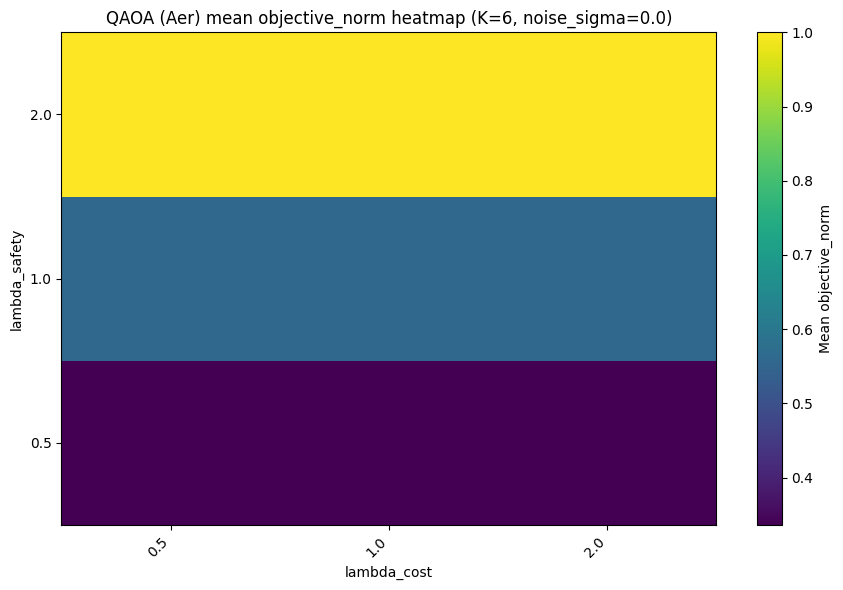

Saved: outputs/figures/05b2_qaoa_aer_objective_heatmap.png


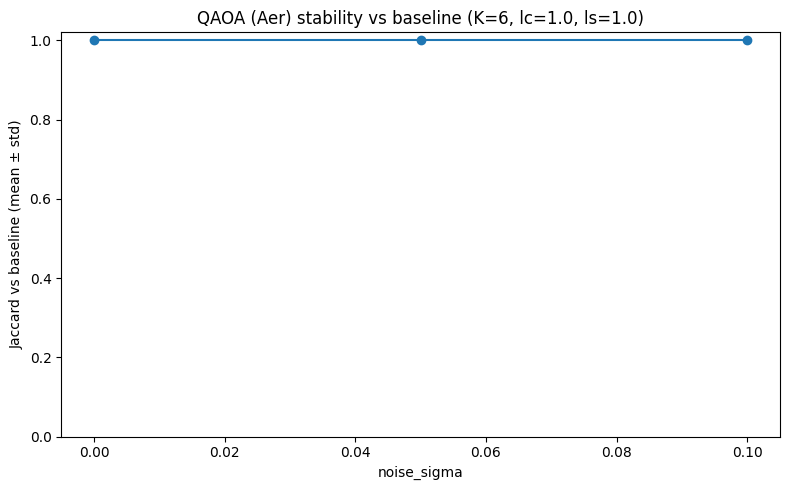

Saved: outputs/figures/05b2_qaoa_aer_jaccard_vs_baseline.png


In [10]:
# ============================================================
# Cell 6 — Visuals: objective heatmap + Jaccard vs noise
# ============================================================

# Heatmap slice (choose a K that exists)
K_HEAT = int(sorted(K_values)[len(K_values) // 2])
SIG_HEAT = 0.0
if SIG_HEAT not in set(agg["noise_sigma"].unique()):
    SIG_HEAT = float(sorted(agg["noise_sigma"].unique())[0])

heat_slice = agg[(agg["K"] == K_HEAT) & (agg["noise_sigma"] == SIG_HEAT)].copy()
if heat_slice.empty:
    raise ValueError(f"No data for heatmap slice K={K_HEAT}, noise_sigma={SIG_HEAT}")

pivot = (
    heat_slice.pivot(index="lambda_safety", columns="lambda_cost", values="objective_norm_mean")
              .sort_index(axis=0)
              .sort_index(axis=1)
)

plt.figure(figsize=(9, 6))
img = plt.imshow(pivot.values, aspect="auto", origin="lower")
plt.colorbar(img, label="Mean objective_norm")
plt.xticks(range(len(pivot.columns)), [str(x) for x in pivot.columns], rotation=45, ha="right")
plt.yticks(range(len(pivot.index)), [str(x) for x in pivot.index])
plt.xlabel("lambda_cost")
plt.ylabel("lambda_safety")
plt.title(f"QAOA (Aer) mean objective_norm heatmap (K={K_HEAT}, noise_sigma={SIG_HEAT})")
plt.tight_layout()
plt.savefig(PATH_FIG_HEATMAP, dpi=160)
plt.show()
print("Saved:", PATH_FIG_HEATMAP)

# Jaccard vs noise for baseline lambdas and baseline K
K_LINE = int(BASELINE["K"])
LC_LINE = float(BASELINE["lambda_cost"])
LS_LINE = float(BASELINE["lambda_safety"])

line_slice = summary_df[
    (summary_df["K"] == K_LINE) &
    (summary_df["lambda_cost"] == LC_LINE) &
    (summary_df["lambda_safety"] == LS_LINE)
].copy()

if line_slice.empty:
    # Fall back to the first available K for the baseline lambdas
    avail_K = sorted(summary_df[
        (summary_df["lambda_cost"] == LC_LINE) &
        (summary_df["lambda_safety"] == LS_LINE)
    ]["K"].unique().tolist())
    if not avail_K:
        raise ValueError("No rows found for baseline lambdas to plot Jaccard vs noise.")
    K_LINE = int(avail_K[0])
    line_slice = summary_df[
        (summary_df["K"] == K_LINE) &
        (summary_df["lambda_cost"] == LC_LINE) &
        (summary_df["lambda_safety"] == LS_LINE)
    ].copy()

line_agg = (
    line_slice.groupby("noise_sigma", as_index=False)
              .agg(jaccard_mean=("jaccard_vs_baseline", "mean"),
                   jaccard_std=("jaccard_vs_baseline", "std"))
              .sort_values("noise_sigma")
)

plt.figure(figsize=(8, 5))
plt.errorbar(line_agg["noise_sigma"], line_agg["jaccard_mean"], yerr=line_agg["jaccard_std"], fmt="-o", capsize=3)
plt.ylim(0, 1.02)
plt.xlabel("noise_sigma")
plt.ylabel("Jaccard vs baseline (mean ± std)")
plt.title(f"QAOA (Aer) stability vs baseline (K={K_LINE}, lc={LC_LINE}, ls={LS_LINE})")
plt.tight_layout()
plt.savefig(PATH_FIG_JACCARD, dpi=160)
plt.show()
print("Saved:", PATH_FIG_JACCARD)

### What Cell 6 Just Did

- Generated and saved a heatmap showing mean normalized objective across `λ_cost × λ_safety` for a representative `(K, noise)` slice.
- Generated and saved a stability plot showing how selection overlap (Jaccard) against the baseline changes as `noise_sigma` increases.
- Included safe fallbacks so the plots still render even when the available K/noise values are constrained by a small candidates set.

In [11]:
# ============================================================
# Cell 7 — Wrap-up: previews, artifact list, sanity checks
# ============================================================

print("Sweep summary preview:")
display(summary_df.head(10))

print("\nAggregated config preview (top by objective_norm_mean):")
display(agg.sort_values(["objective_norm_mean", "jaccard_mean"], ascending=[False, False]).head(12))

print("\nArtifacts written:")
print("  -", PATH_SWEEP_SUMMARY)
print("  -", PATH_TOP_TABLE)
print("  -", PATH_TOP_SELECTED)
print("  -", PATH_CHECKPOINT)
print("  -", PATH_FIG_HEATMAP)
print("  -", PATH_FIG_JACCARD)

# Sanity checks
assert summary_df["selected_n"].min() >= 0
assert summary_df["selected_n"].max() <= POOL_SIZE
assert summary_df["objective_norm"].between(0, 1).all()

print("\nSanity checks passed.")


Sweep summary preview:


,config_id,K,lambda_cost,lambda_safety,noise_sigma,seed,pool_size,penalty_A,shots,gamma_0,beta_0,best_mean_energy,best_bitstring,jaccard_vs_baseline,selected_n,total_benefit,total_cost,total_safety,objective,objective_norm
0,K3_lc0.5_ls0.5_sig0.0_seed0_pool6_shots1024_A10.0,3,0.5,0.5,0.00,0,6,10.0,1024,1.000000,0.200000,-80.462891,100110,0.5,3,0.000000,0.000000,3.000000,1.500000,0.225127
1,K3_lc0.5_ls0.5_sig0.0_seed1_pool6_shots1024_A10.0,3,0.5,0.5,0.00,1,6,10.0,1024,1.000000,0.200000,-81.067383,100011,0.5,3,0.000000,0.000000,3.000000,1.500000,0.225127
2,K3_lc0.5_ls0.5_sig0.0_seed2_pool6_shots1024_A10.0,3,0.5,0.5,0.00,2,6,10.0,1024,1.000000,0.200000,-80.576172,011100,0.5,3,0.000000,0.000000,3.000000,1.500000,0.225127
3,K3_lc0.5_ls0.5_sig0.05_seed0_pool6_shots1024_A...,3,0.5,0.5,0.05,0,6,10.0,1024,1.533333,1.266667,-86.132201,101100,0.5,3,2.307580,0.736216,0.777739,-1.550602,0.000000
4,K3_lc0.5_ls0.5_sig0.05_seed1_pool6_shots1024_A...,3,0.5,0.5,0.05,1,6,10.0,1024,1.533333,1.266667,-86.304457,010011,0.5,3,2.708623,1.507998,1.989201,-0.960024,0.043583
5,K3_lc0.5_ls0.5_sig0.05_seed2_pool6_shots1024_A...,3,0.5,0.5,0.05,2,6,10.0,1024,1.533333,1.266667,-85.868724,110001,0.5,3,2.465668,1.311331,1.515278,-1.052363,0.036769
6,K3_lc0.5_ls0.5_sig0.1_seed0_pool6_shots1024_A10.0,3,0.5,0.5,0.10,0,6,10.0,1024,1.533333,1.266667,-86.147731,101100,0.5,3,2.307580,0.745307,0.777739,-1.546057,0.000335
7,K3_lc0.5_ls0.5_sig0.1_seed1_pool6_shots1024_A10.0,3,0.5,0.5,0.10,1,6,10.0,1024,1.533333,1.266667,-86.284224,010011,0.5,3,2.708623,1.510325,1.989201,-0.958861,0.043669
8,K3_lc0.5_ls0.5_sig0.1_seed2_pool6_shots1024_A10.0,3,0.5,0.5,0.10,2,6,10.0,1024,1.533333,1.266667,-85.838853,110001,0.5,3,2.465668,1.314680,1.515278,-1.050689,0.036892
9,K3_lc0.5_ls1.0_sig0.0_seed0_pool6_shots1024_A10.0,3,0.5,1.0,0.00,0,6,10.0,1024,1.000000,0.200000,-74.191406,010110,0.5,3,0.000000,0.000000,3.000000,3.000000,0.335823



Aggregated config preview (top by objective_norm_mean):


,K,lambda_cost,lambda_safety,noise_sigma,pool_size,penalty_A,shots,objective_mean,objective_std,objective_norm_mean,jaccard_mean,jaccard_std,n_runs
33,6,0.5,2.0,0.00,6,10.0,1024,12.000000,0.000000,1.000000,1.0,0.0,3
42,6,1.0,2.0,0.00,6,10.0,1024,12.000000,0.000000,1.000000,1.0,0.0,3
51,6,2.0,2.0,0.00,6,10.0,1024,12.000000,0.000000,1.000000,1.0,0.0,3
53,6,2.0,2.0,0.10,6,10.0,1024,8.453292,2.197482,0.738262,1.0,0.0,3
52,6,2.0,2.0,0.05,6,10.0,1024,8.433709,2.206996,0.736817,1.0,0.0,3
30,6,0.5,1.0,0.00,6,10.0,1024,6.000000,0.000000,0.557215,1.0,0.0,3
39,6,1.0,1.0,0.00,6,10.0,1024,6.000000,0.000000,0.557215,1.0,0.0,3
48,6,2.0,1.0,0.00,6,10.0,1024,6.000000,0.000000,0.557215,1.0,0.0,3
6,3,0.5,2.0,0.00,6,10.0,1024,6.000000,0.000000,0.557215,0.5,0.0,3
15,3,1.0,2.0,0.00,6,10.0,1024,6.000000,0.000000,0.557215,0.5,0.0,3



Artifacts written:
  - data/results/05b2_qaoa_aer_robustness_sweep_summary.csv
  - data/results/05b2_qaoa_aer_top_config_table.csv
  - data/results/05b2_qaoa_aer_top_configs_selected_trials.csv
  - data/results/05b2_qaoa_aer_checkpoint_partial.csv
  - outputs/figures/05b2_qaoa_aer_objective_heatmap.png
  - outputs/figures/05b2_qaoa_aer_jaccard_vs_baseline.png

Sanity checks passed.


### What Cell 7 Just Did

- Displayed previews of the raw sweep output (`summary_df`) and the aggregated config table (`agg`).
- Printed all on-disk artifact paths created by this standalone Aer run.
- Verified basic sanity checks: selections never exceed the pool size and objective normalization is within [0,1].


## Summary

This standalone notebook (`05b2_robustness_sweeps_scenario_A_qaoa_aer.ipynb`) ran an **Aer-backed QAOA** robustness sweep for Scenario A with:

- normalized benefit/cost/safety components derived from the Scenario A candidates table,
- an exact-K QUBO penalty model, optimized via p=1 QAOA sampling on Aer,
- a **fixed candidate pool** so comparisons across configurations are meaningful,
- robustness evaluation via noise on raw features and multiple seeds,
- export of sweep results, top configs, selected trials, and two slide-friendly figures.

Notes / Next:
- If your candidates dataset is very small (e.g., 6 rows), this run is best treated as a **pipeline smoke test**.
- For a meaningful robustness analysis, point `PATH_CANDIDATES_PRIMARY` to the full Scenario A candidate universe (dozens+ rows).
- Once you have a full candidates table, consider increasing:
  - `TARGET_POOL_SIZE` (e.g., 18 → 24)
  - `seeds` (e.g., [0,1,2] → [0..4])
  - and/or the angle grid to 9×9 if runtime permits.
